# Task 1: Preprocess and Explore the Data

This notebook extracts historical financial data for **TSLA**, **BND**, and **SPY** from yfinance covering the period from January 1, 2015 to June 30, 2026. We perform data cleaning, exploratory data analysis, stationarity testing, and calculate risk metrics.

In [1]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import fetch_data, clean_data, save_data
from src.eda_utils import (
    calculate_daily_returns, calculate_rolling_stats, detect_outliers,
    run_adf_test, calculate_var, calculate_sharpe_ratio,
    calculate_cvar, calculate_max_drawdown, calculate_sortino_ratio,
    calculate_skewness, calculate_kurtosis, run_jarque_bera_test
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import norm

## 1. Extract Historical Financial Data
We download the data using `yfinance` from Jan 1, 2015 to June 30, 2026.

In [2]:
tickers = ["TSLA", "BND", "SPY"]
raw_data = fetch_data(tickers, start_date="2015-01-01", end_date="2026-06-30")
cleaned_data = clean_data(raw_data)
save_data(cleaned_data, output_dir="../data/processed")

Fetching data for tickers: ['TSLA', 'BND', 'SPY'] from 2015-01-01 to 2026-06-30...


[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

[*********************100%***********************]  1 of 1 completed

Saved TSLA data to ../data/processed\TSLA_cleaned.csv
Saved BND data to ../data/processed\BND_cleaned.csv
Saved SPY data to ../data/processed\SPY_cleaned.csv


## 2. Basic Data Statistics and Distributions

In [3]:
for ticker in tickers:
    print(f"\n--- Basic Statistics for {ticker} ---")
    print(cleaned_data[ticker].describe())


--- Basic Statistics for TSLA ---
Price         Open         High          Low        Close    Adj Close  \
count  2888.000000  2888.000000  2888.000000  2888.000000  2888.000000   
mean    148.797341   151.990563   145.416731   148.773923   148.773923   
std     138.977191   141.852818   135.867193   138.895957   138.895957   
min       9.488000    10.331333     9.403333     9.578000     9.578000   
25%      18.390833    18.665168    18.023666    18.393499    18.393499   
50%     131.496330   136.053329   125.831669   133.437668   133.437668   
75%     251.680004   257.485008   245.832500   251.925831   251.925831   
max     489.880005   498.829987   485.329987   489.880005   489.880005   

Price        Volume  
count  2.888000e+03  
mean   1.087922e+08  
std    7.082549e+07  
min    1.062000e+07  
25%    6.548325e+07  
50%    9.033615e+07  
75%    1.261204e+08  
max    9.140820e+08  

--- Basic Statistics for BND ---
Price         Open         High          Low        Close    Adj C

## 3. Exploratory Data Analysis (EDA)

### A. Visualizing Closing Price over Time

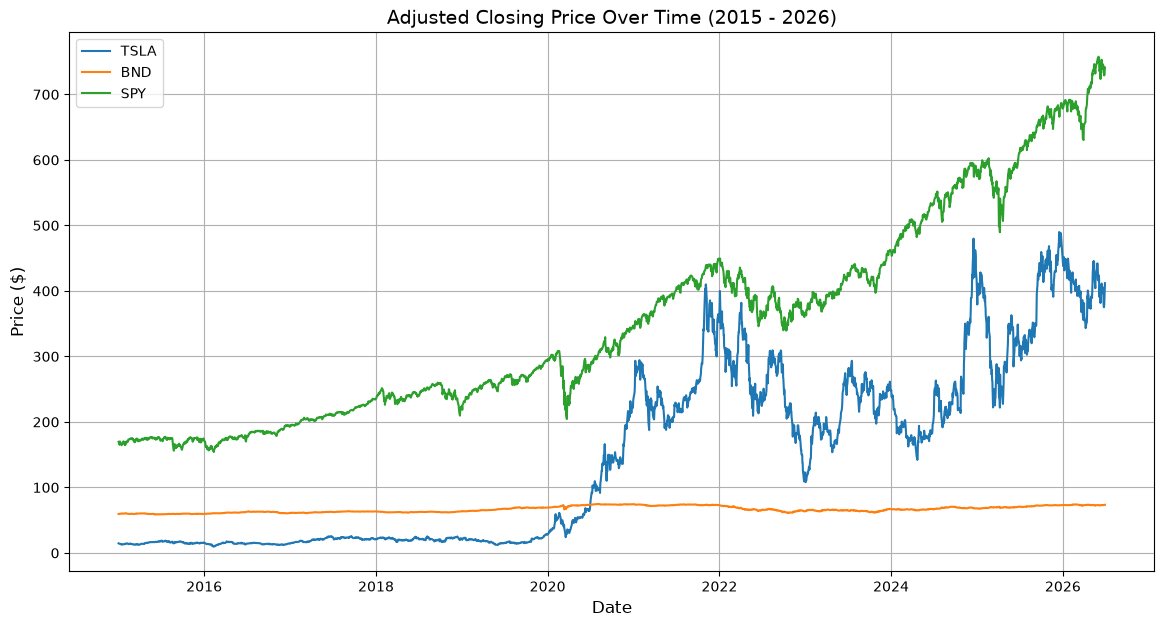

In [4]:
plt.figure(figsize=(14, 7))
for ticker in tickers:
    plt.plot(cleaned_data[ticker]['Adj Close'], label=ticker)
plt.title("Adjusted Closing Price Over Time (2015 - 2026)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### B. Daily Percentage Change (Returns)
Observing daily return volatility.

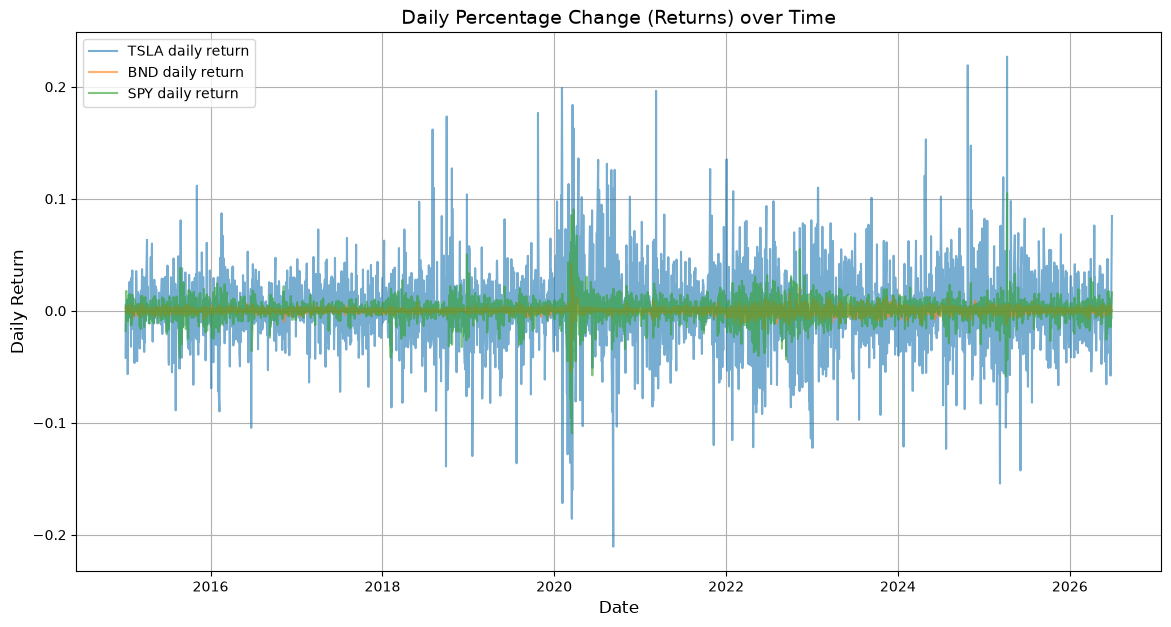

In [5]:
returns_dict = {}
plt.figure(figsize=(14, 7))
for ticker in tickers:
    returns_dict[ticker] = calculate_daily_returns(cleaned_data[ticker])
    plt.plot(returns_dict[ticker], label=f"{ticker} daily return", alpha=0.6)
plt.title("Daily Percentage Change (Returns) over Time", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Return", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### C. Volatility Analysis (20-day Rolling Mean & Standard Deviation)

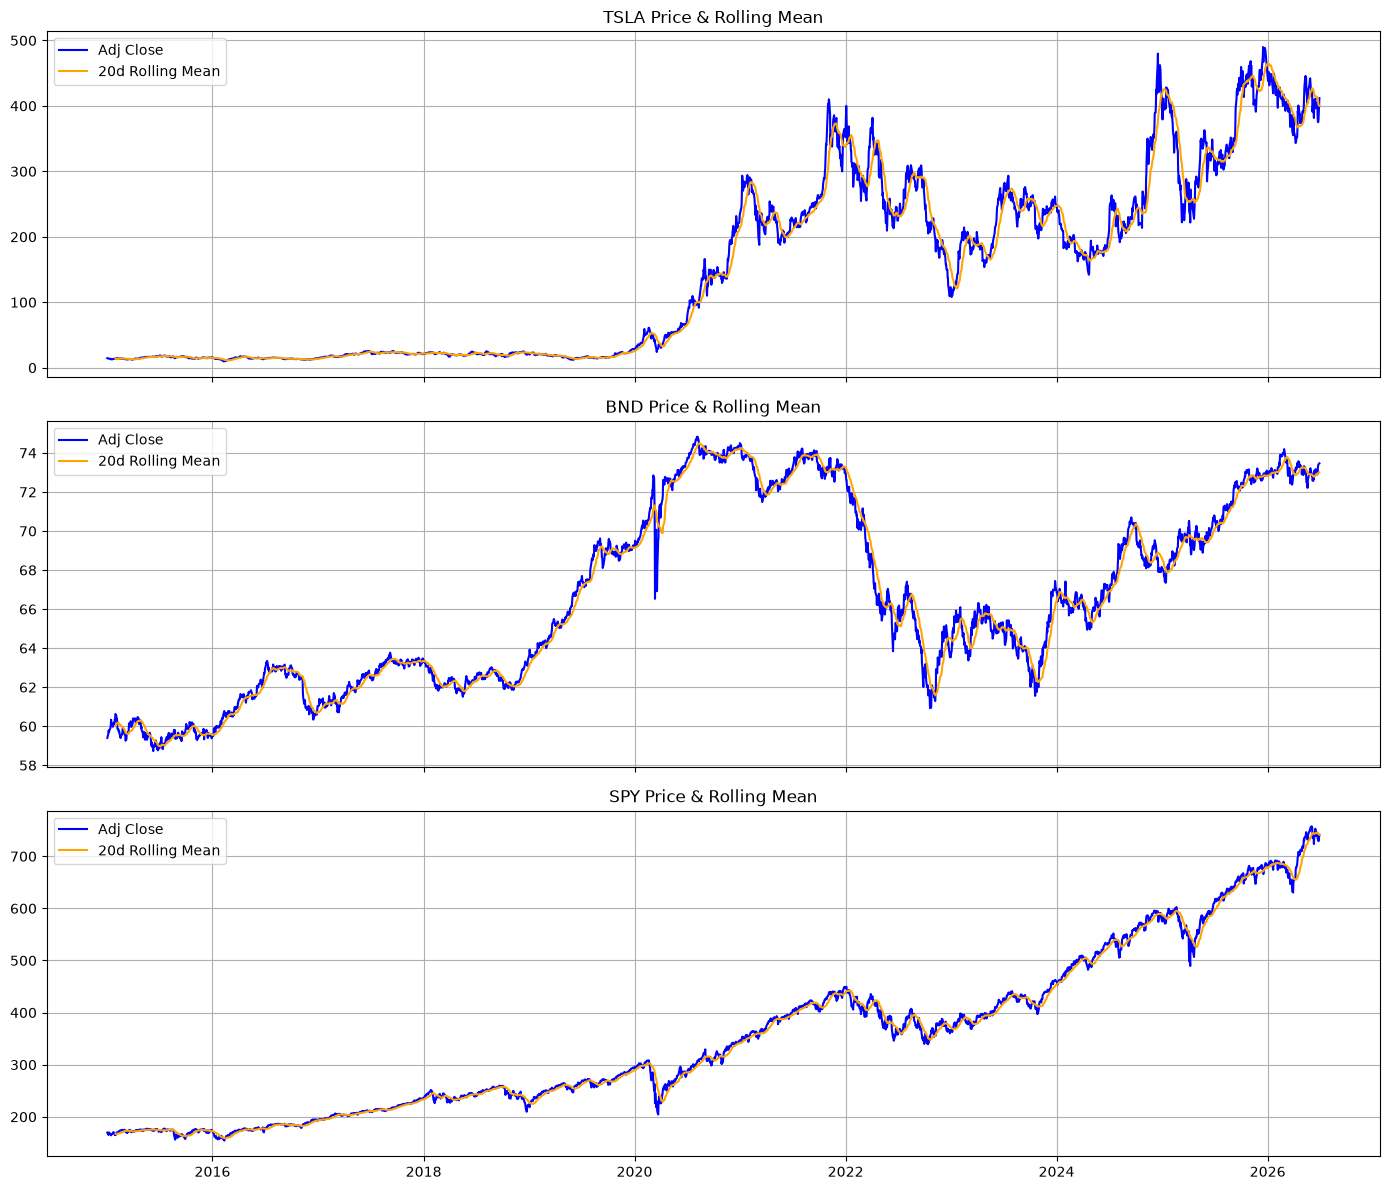

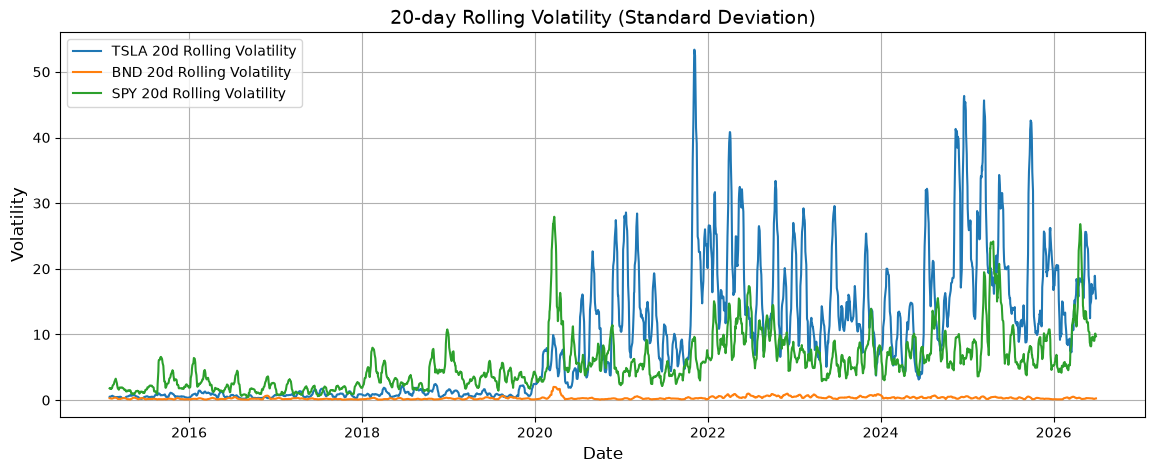

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for i, ticker in enumerate(tickers):
    roll_mean, roll_std = calculate_rolling_stats(cleaned_data[ticker], window=20)
    axes[i].plot(cleaned_data[ticker]['Adj Close'], label='Adj Close', color='blue')
    axes[i].plot(roll_mean, label='20d Rolling Mean', color='orange')
    axes[i].set_title(f"{ticker} Price & Rolling Mean", fontsize=12)
    axes[i].legend()
    axes[i].grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
for ticker in tickers:
    _, roll_std = calculate_rolling_stats(cleaned_data[ticker], window=20)
    plt.plot(roll_std, label=f"{ticker} 20d Rolling Volatility")
plt.title("20-day Rolling Volatility (Standard Deviation)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Volatility", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

### D. Normality Diagnostics: Distribution & Box Plots
We overlay return histograms with normal distribution curves and plot return boxplots to evaluate fat tails and outliers.

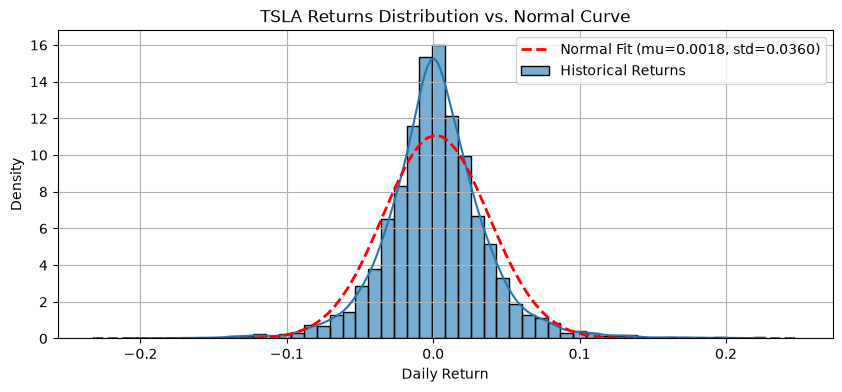

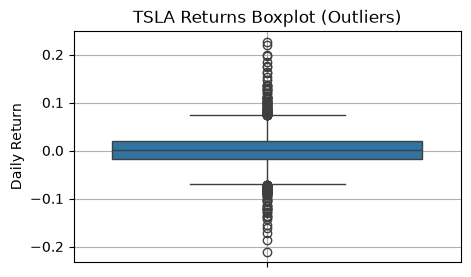

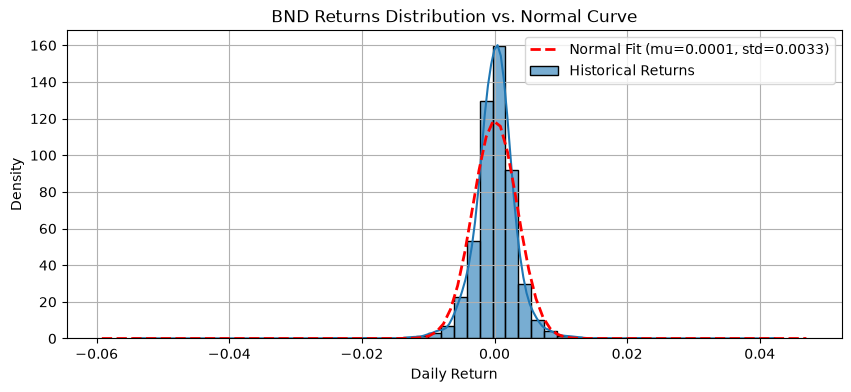

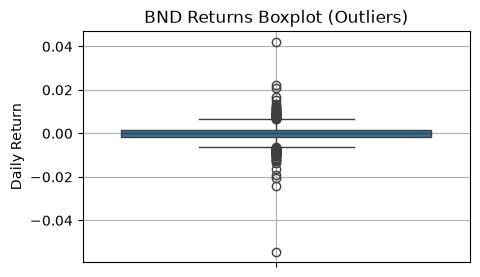

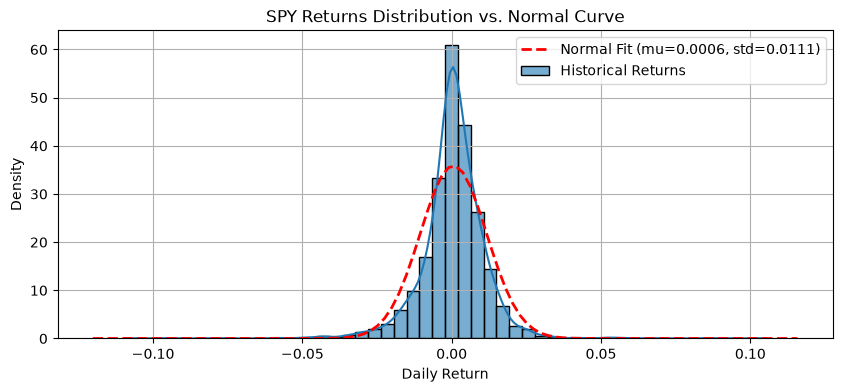

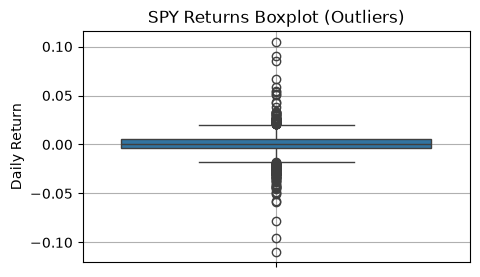

In [7]:
for ticker in tickers:
    rets = returns_dict[ticker]
    plt.figure(figsize=(10, 4))
    sns.histplot(rets, kde=True, stat="density", label="Historical Returns", bins=50, alpha=0.6)
    
    # Normal curve fit overlay
    mu, std = norm.fit(rets)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    plt.plot(x, p, 'r--', linewidth=2, label=f"Normal Fit (mu={mu:.4f}, std={std:.4f})")
    
    plt.title(f"{ticker} Returns Distribution vs. Normal Curve", fontsize=12)
    plt.xlabel("Daily Return")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=rets)
    plt.title(f"{ticker} Returns Boxplot (Outliers)", fontsize=12)
    plt.ylabel("Daily Return")
    plt.grid(True)
    plt.show()

### E. Autocorrelation (ACF / PACF) Analysis
We construct ACF and PACF plots for daily returns to study correlation patterns before modeling.

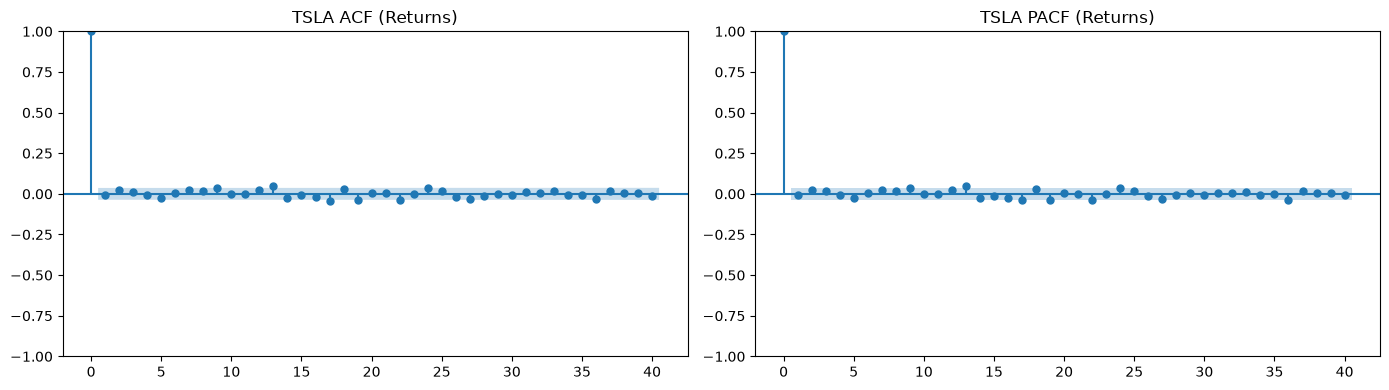

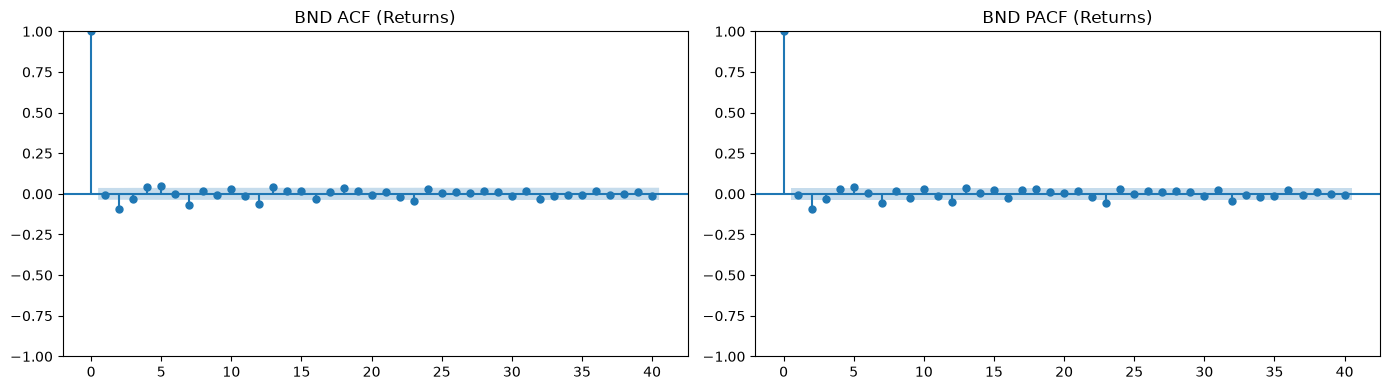

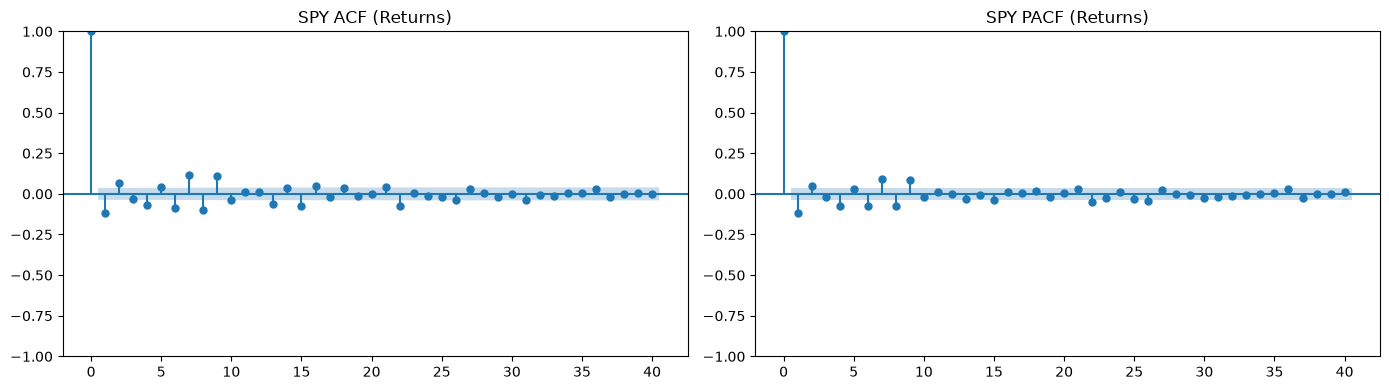

In [8]:
for ticker in tickers:
    rets = returns_dict[ticker]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(rets, lags=40, ax=ax1, title=f"{ticker} ACF (Returns)")
    plot_pacf(rets, lags=40, ax=ax2, title=f"{ticker} PACF (Returns)")
    plt.tight_layout()
    plt.show()

### F. Time Series Decomposition (Trend, Seasonal, Residual)
We decompose the adjusted closing prices to visualize trend and seasonal components over a 365d daily period.

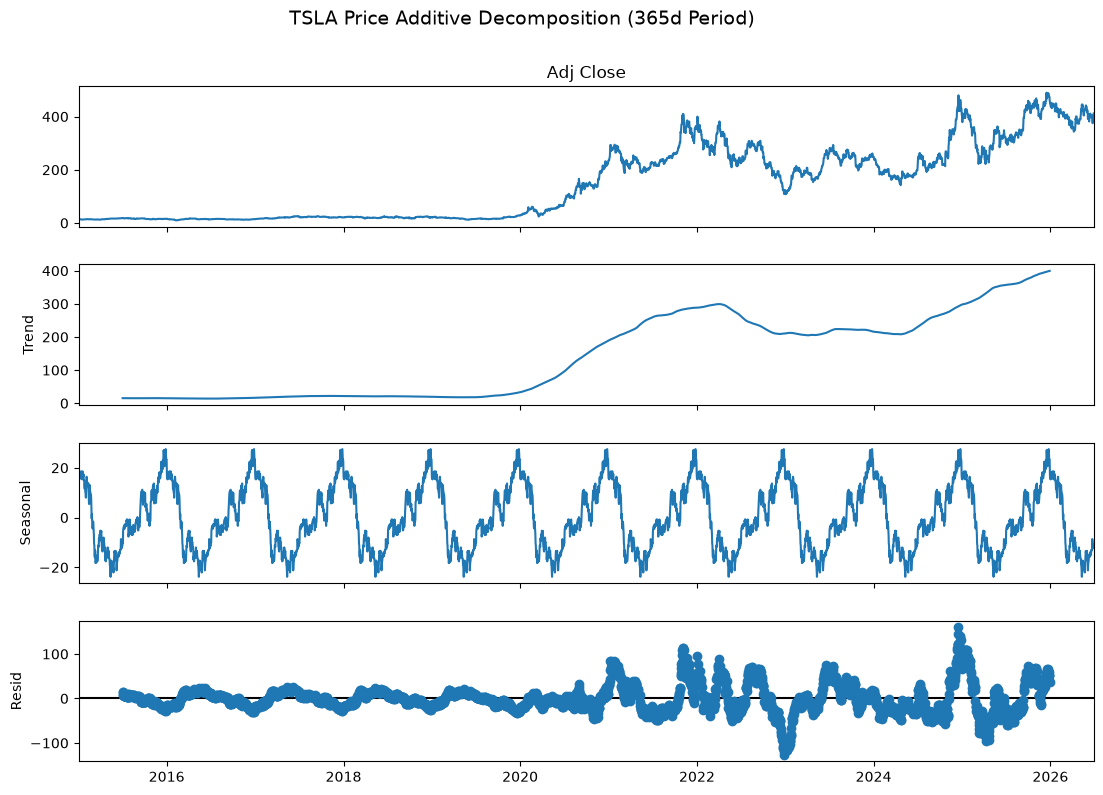

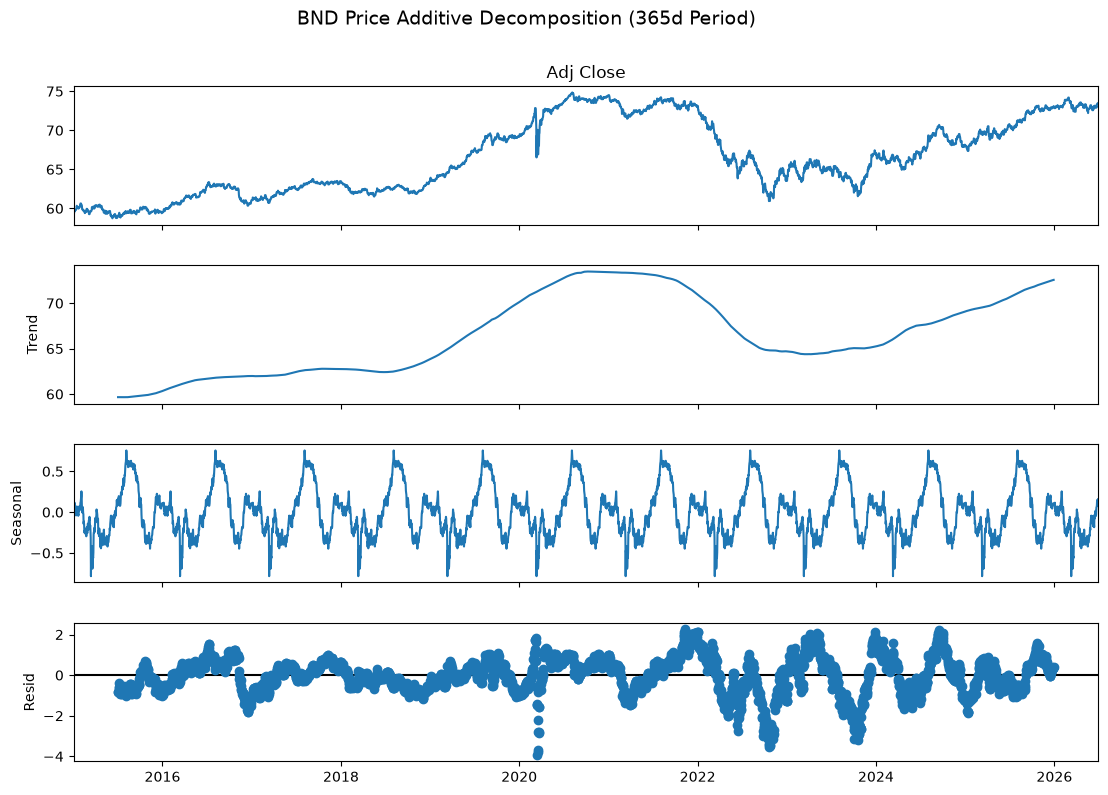

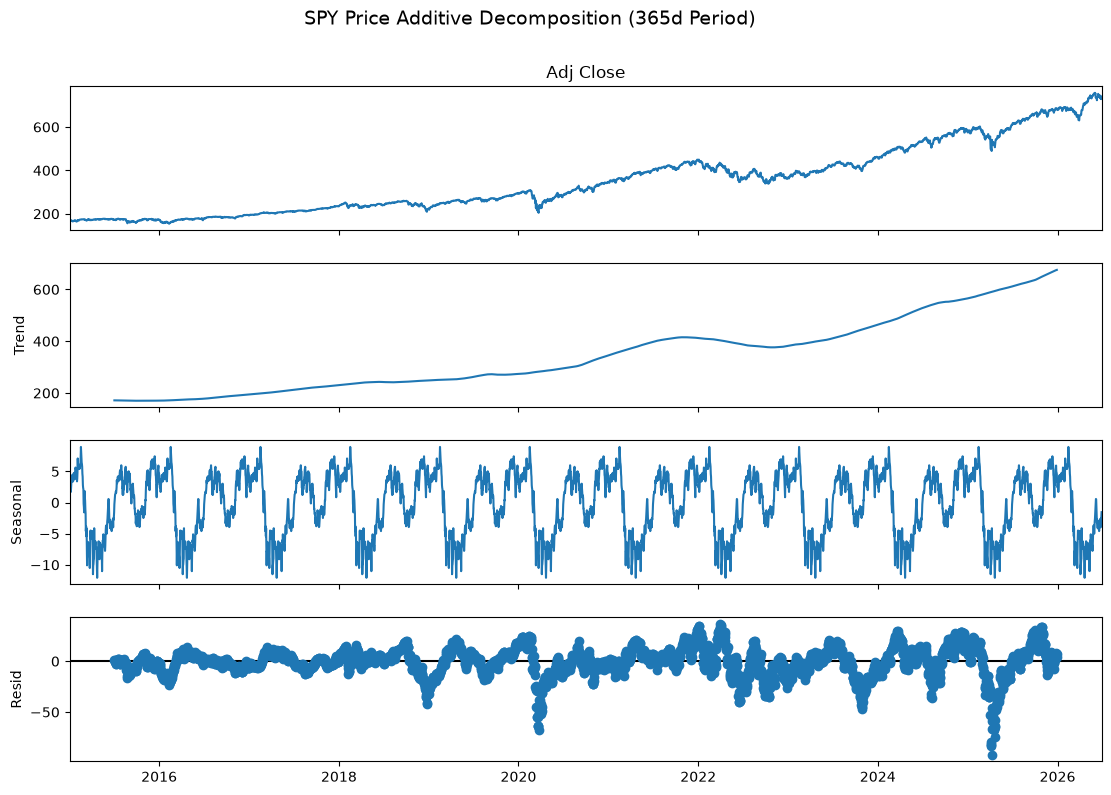

In [9]:
for ticker in tickers:
    prices = cleaned_data[ticker]['Adj Close']
    prices_resampled = prices.asfreq('D').ffill()
    result = seasonal_decompose(prices_resampled, model='additive', period=365)
    
    fig = result.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle(f"{ticker} Price Additive Decomposition (365d Period)", y=1.02, fontsize=14)
    plt.show()

### G. Outlier Detection
Identify dates where daily returns are greater than 3 standard deviations away from the mean.

In [10]:
for ticker in tickers:
    outliers = detect_outliers(returns_dict[ticker], threshold=3.0)
    print(f"\n{ticker} has {len(outliers)} outliers using a 3-standard-deviation threshold.")
    print("Top 5 most extreme outlier days:")
    print(outliers.abs().sort_values(ascending=False).head(5))


TSLA has 46 outliers using a 3-standard-deviation threshold.
Top 5 most extreme outlier days:
Date
2025-04-09    0.226900
2024-10-24    0.219190
2020-09-08    0.210628
2020-02-03    0.198949
2021-03-09    0.196412
Name: Adj Close, dtype: float64

BND has 33 outliers using a 3-standard-deviation threshold.
Top 5 most extreme outlier days:
Date
2020-03-12    0.054385
2020-03-13    0.042201
2020-03-18    0.024141
2020-03-23    0.022149
2022-11-10    0.020702
Name: Adj Close, dtype: float64

SPY has 39 outliers using a 3-standard-deviation threshold.
Top 5 most extreme outlier days:
Date
2020-03-16    0.109424
2025-04-09    0.105019
2020-03-12    0.095677
2020-03-24    0.090603
2020-03-13    0.085486
Name: Adj Close, dtype: float64


## 4. Seasonality and Trend Analysis (ADF Stationarity Test)

We run the Augmented Dickey-Fuller (ADF) test on both closing prices and daily returns.

In [11]:
for ticker in tickers:
    print(f"\n=== ADF Test for {ticker} ===")
    price_adf = run_adf_test(cleaned_data[ticker]['Adj Close'])
    print(f"Adj Close - ADF Stat: {price_adf['adf_stat']:.4f}, p-value: {price_adf['p_value']:.4e}")
    print(f"  Is stationary? {price_adf['is_stationary']}")
    
    ret_adf = run_adf_test(returns_dict[ticker])
    print(f"Daily Returns - ADF Stat: {ret_adf['adf_stat']:.4f}, p-value: {ret_adf['p_value']:.4e}")
    print(f"  Is stationary? {ret_adf['is_stationary']}")


=== ADF Test for TSLA ===
Adj Close - ADF Stat: -1.0696, p-value: 7.2704e-01
  Is stationary? False
Daily Returns - ADF Stat: -53.9719, p-value: 0.0000e+00
  Is stationary? True

=== ADF Test for BND ===


Adj Close - ADF Stat: -1.0827, p-value: 7.2192e-01
  Is stationary? False
Daily Returns - ADF Stat: -15.2161, p-value: 5.5680e-28
  Is stationary? True

=== ADF Test for SPY ===
Adj Close - ADF Stat: 1.3089, p-value: 9.9666e-01
  Is stationary? False


Daily Returns - ADF Stat: -17.5722, p-value: 4.0463e-30
  Is stationary? True


## 5. Risk & Statistics Diagnostics

In [12]:
for ticker in tickers:
    var_95 = calculate_var(returns_dict[ticker], confidence_level=0.95)
    var_99 = calculate_var(returns_dict[ticker], confidence_level=0.99)
    cvar_95 = calculate_cvar(returns_dict[ticker], confidence_level=0.95)
    cvar_99 = calculate_cvar(returns_dict[ticker], confidence_level=0.99)
    max_dd = calculate_max_drawdown(cleaned_data[ticker]['Adj Close'])
    sharpe = calculate_sharpe_ratio(returns_dict[ticker])
    sortino = calculate_sortino_ratio(returns_dict[ticker])
    skewness = calculate_skewness(returns_dict[ticker])
    kurtosis = calculate_kurtosis(returns_dict[ticker])
    jb_res = run_jarque_bera_test(returns_dict[ticker])
    
    print(f"\n--- Advanced Risk & Normality Metrics for {ticker} ---")
    print(f"Value at Risk (95% Confidence): {var_95*100:.2f}%")
    print(f"Value at Risk (99% Confidence): {var_99*100:.2f}%")
    print(f"Conditional VaR (95% Confidence): {cvar_95*100:.2f}%")
    print(f"Conditional VaR (99% Confidence): {cvar_99*100:.2f}%")
    print(f"Maximum Historical Drawdown: {max_dd*100:.2f}%")
    print(f"Annualized Sharpe Ratio: {sharpe:.4f}")
    print(f"Annualized Sortino Ratio: {sortino:.4f}")
    print(f"Skewness: {skewness:.4f}")
    print(f"Excess Kurtosis: {kurtosis:.4f}")
    print(f"Jarque-Bera Stat: {jb_res['jb_stat']:.2f}, p-value: {jb_res['p_value']:.4e}")
    print(f"Is return normally distributed? {jb_res['is_normal']}")


--- Advanced Risk & Normality Metrics for TSLA ---
Value at Risk (95% Confidence): 5.17%
Value at Risk (99% Confidence): 8.99%
Conditional VaR (95% Confidence): 7.86%
Conditional VaR (99% Confidence): 12.50%
Maximum Historical Drawdown: -73.63%
Annualized Sharpe Ratio: 0.7944
Annualized Sortino Ratio: 0.8319
Skewness: 0.2933
Excess Kurtosis: 4.4572
Jarque-Bera Stat: 2431.16, p-value: 0.0000e+00
Is return normally distributed? False

--- Advanced Risk & Normality Metrics for BND ---
Value at Risk (95% Confidence): 0.48%
Value at Risk (99% Confidence): 0.86%
Conditional VaR (95% Confidence): 0.74%
Conditional VaR (99% Confidence): 1.31%
Maximum Historical Drawdown: -18.58%
Annualized Sharpe Ratio: 0.3756
Annualized Sortino Ratio: 0.3547
Skewness: -0.9167
Excess Kurtosis: 36.4276
Jarque-Bera Stat: 160027.89, p-value: 0.0000e+00
Is return normally distributed? False

--- Advanced Risk & Normality Metrics for SPY ---
Value at Risk (95% Confidence): 1.67%
Value at Risk (99% Confidence): 3.1